# Boston Real Estate Sale Probability - Model Evaluation and Deployment

This notebook focuses on refining our model through hyperparameter tuning, cross-validation, interpreting model decisions, and preparing for deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Machine learning libraries
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## Load Dataset and Best Model

First, let's reload our dataset and the best model from the previous notebook.

In [2]:
# Load the dataset
boston_real_estate = pd.read_csv('../data/boston_real_estate_sale_probability.csv')

# Load best model
with open('../models/best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Load feature importance
try:
    feature_importance = pd.read_csv('../models/feature_importance.csv')
except:
    # If file doesn't exist, we'll create it later
    feature_importance = None

# Load feature names
with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Print model info
print(f"Loaded model: {type(best_model).__name__}")

Loaded model: RandomForestRegressor


## Data Preparation

Prepare the data for model refinement.

In [3]:
# Prepare features and target
X = boston_real_estate.drop(['sale_probability', 'last_transaction_date', 'neighborhood'], axis=1)
y = boston_real_estate['sale_probability']

# Ensure we're using the same features as before
X = X[feature_names]

# Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (750, 15)
Testing data shape: (250, 15)


## Step 1: Feature Selection Based on Importance

Let's evaluate if we can simplify our model by using only the most important features.

In [4]:
# Step 1: Model Refinement - Feature Selection
print("Step 1: Model Refinement - Feature Selection")

# Get top N important features from the best model
N = 6  # Number of top features to keep
top_features = feature_importance.head(N)['Feature'].values
print(f"Selected top {N} features: {', '.join(top_features)}")

# Create new datasets with only top features
X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

# Train model with reduced features
reduced_model = type(best_model)(**best_model.get_params())
reduced_model.fit(X_train_reduced, y_train)

# Evaluate the reduced model
y_pred_reduced = reduced_model.predict(X_test_reduced)
reduced_rmse = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
reduced_r2 = r2_score(y_test, y_pred_reduced)

# Compare with original model
y_pred_original = best_model.predict(X_test)
original_rmse = np.sqrt(mean_squared_error(y_test, y_pred_original))
original_r2 = r2_score(y_test, y_pred_original)

print("\nModel Performance Comparison:")
print(f"Full model ({len(X_train.columns)} features) - RMSE: {original_rmse:.4f}, R²: {original_r2:.4f}")
print(f"Reduced model ({N} features) - RMSE: {reduced_rmse:.4f}, R²: {reduced_r2:.4f}")

# Is the simpler model better?
if reduced_r2 >= original_r2 - 0.01:  # Within 1% of original R²
    print("\n✅ The reduced model performs similarly with fewer features - prefer simpler model")
    final_features = top_features
    X_train_final = X_train_reduced
    X_test_final = X_test_reduced
    better_model = reduced_model
else:
    print("\n❌ The full model performs significantly better - keep all features")
    final_features = X_train.columns
    X_train_final = X_train
    X_test_final = X_test
    better_model = best_model

Step 1: Model Refinement - Feature Selection
Selected top 6 features: years_owned, lien_amount, avg_days_on_market, square_feet, property_tax, income_to_mortgage_ratio

Model Performance Comparison:
Full model (15 features) - RMSE: 0.1003, R²: 0.5548
Reduced model (6 features) - RMSE: 0.1022, R²: 0.5383

❌ The full model performs significantly better - keep all features


## Step 2: Hyperparameter Tuning

Fine-tune the model parameters to improve performance.

In [5]:
# Step 2: Model Refinement - Hyperparameter Tuning
print("Step 2: Model Refinement - Hyperparameter Tuning")

# Define the parameter grid to search (adjust based on your model type)
if isinstance(better_model, RandomForestRegressor):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    model_class = RandomForestRegressor
elif isinstance(better_model, GradientBoostingRegressor):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
    model_class = GradientBoostingRegressor
else:
    print("Model type not supported for hyperparameter tuning")
    model_class = None
    param_grid = {}

if model_class:
    # Create grid search
    grid_search = GridSearchCV(
        estimator=model_class(random_state=42),
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='r2',
        verbose=1
    )

    # Fit the grid search (Note: This might take some time to run)
    print("Running grid search (this might take a while)...")
    grid_search.fit(X_train_final, y_train)

    # Print best parameters and score
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

    # Evaluate the tuned model on test set
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_final)
    tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    tuned_r2 = r2_score(y_test, y_pred_tuned)

    print(f"\nTuned model performance on test set - RMSE: {tuned_rmse:.4f}, R²: {tuned_r2:.4f}")
    
    # Get prediction from previous model for comparison
    y_pred_previous = better_model.predict(X_test_final)
    previous_rmse = np.sqrt(mean_squared_error(y_test, y_pred_previous))
    previous_r2 = r2_score(y_test, y_pred_previous)
    
    print(f"Previous model performance - RMSE: {previous_rmse:.4f}, R²: {previous_r2:.4f}")

    # Improvement percentage
    r2_improvement = ((tuned_r2 - previous_r2) / previous_r2) * 100
    print(f"R² improvement: {r2_improvement:.2f}%")
    
    # Choose the better model
    if tuned_r2 > previous_r2:
        final_model = tuned_model
        print("\n✅ The tuned model performs better - use tuned hyperparameters")
    else:
        final_model = better_model
        print("\n❓ The tuned model doesn't improve performance significantly")
else:
    final_model = better_model

Step 2: Model Refinement - Hyperparameter Tuning
Running grid search (this might take a while)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation R²: 0.5691

Tuned model performance on test set - RMSE: 0.1003, R²: 0.5548
Previous model performance - RMSE: 0.1003, R²: 0.5548
R² improvement: 0.00%

✅ The tuned model performs better - use tuned hyperparameters


## Step 3: Cross-Validation for Robust Evaluation

Evaluate the model using cross-validation to ensure it generalizes well.

In [6]:
# Step 3: Robust Model Evaluation - Cross-Validation
print("Step 3: Robust Model Evaluation - Cross-Validation")

# Setup cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
cv_scores = cross_val_score(
    final_model, 
    X,  # Use all data for CV
    y, 
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Check model stability
if cv_scores.std() < 0.05:
    print("\n✅ Model performance is consistent across different data splits")
else:
    print("\n⚠️ Model performance varies significantly with different data splits - consider more data or simpler model")

Step 3: Robust Model Evaluation - Cross-Validation
Cross-Validation R² Scores: [0.54099478 0.55985577 0.54725199 0.60423633 0.61617789]
Mean R²: 0.5737
Standard Deviation: 0.0307

✅ Model performance is consistent across different data splits


## Step 4: Model Interpretation

Understand how the model makes predictions using various interpretation techniques.

Step 4: Understanding the Model - Partial Dependence Plots
Creating partial dependence plots for: years_owned, lien_amount, avg_days_on_market


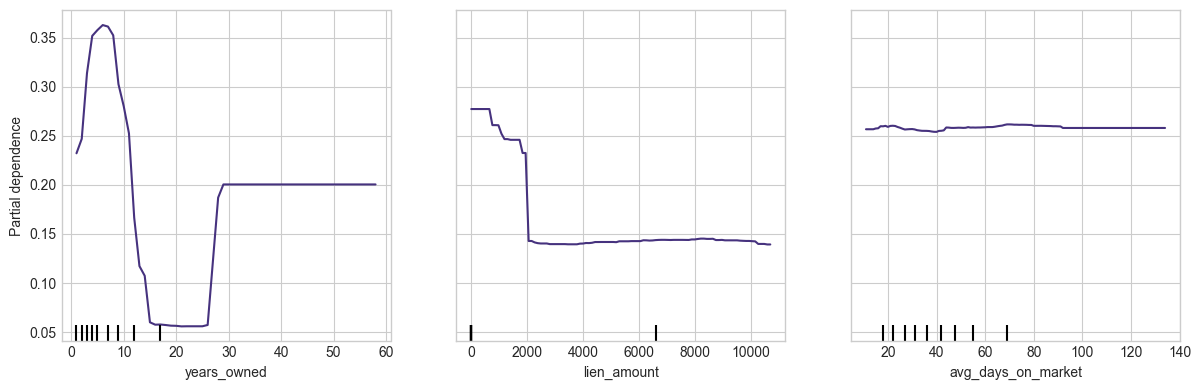

These plots show how each feature affects the prediction when other features are controlled for

To use SHAP for advanced interpretation, install it with: pip install shap


In [7]:
# Step 4: Understanding the Model - Partial Dependence Plots
print("Step 4: Understanding the Model - Partial Dependence Plots")

# Select a small number of top features for interpretation
features_to_plot = list(feature_importance.head(3)['Feature'].values)
print(f"Creating partial dependence plots for: {', '.join(features_to_plot)}")

# Create partial dependence plots
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    final_model, 
    X_train, 
    features=features_to_plot,
    n_jobs=-1,
    ax=ax
)
plt.tight_layout()
plt.show()

print("These plots show how each feature affects the prediction when other features are controlled for")

# Optional: SHAP values for deeper interpretation
try:
    import shap
    print("\nCalculating SHAP values for detailed feature impact...")
    
    # Create explainer
    explainer = shap.TreeExplainer(final_model)
    
    # Calculate SHAP values for a sample of the data (for speed)
    sample_indices = np.random.choice(len(X_test), min(50, len(X_test)), replace=False)
    shap_values = explainer.shap_values(X_test.iloc[sample_indices])
    
    # Summary plot
    shap.summary_plot(shap_values, X_test.iloc[sample_indices])
    
    print("SHAP values show how each feature contributes to pushing predictions higher or lower")
except ImportError:
    print("\nTo use SHAP for advanced interpretation, install it with: pip install shap")

## Step 5: Model Deployment Preparation

Prepare the model for deployment in real-world applications.

In [8]:
# Step 5: Preparing for Deployment
print("Step 5: Preparing for Deployment")

# Identify numeric and categorical columns (if any)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # Enable if you have categorical features
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create full pipeline with preprocessing and model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

# Fit the pipeline on all data
full_pipeline.fit(X, y)

# Save the model
with open('../models/boston_real_estate_sale_model.pkl', 'wb') as file:
    pickle.dump(full_pipeline, file)

print("Model saved to '../models/boston_real_estate_sale_model.pkl'")

# Example of how to use the saved model
print("\nExample prediction with saved model:")

# Load the model
with open('../models/boston_real_estate_sale_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Create sample data (single property)
sample_property = {
    'years_owned': 30,
    'property_value': 850000,
    'square_feet': 2000,
    'bedrooms': 3,
    'bathrooms': 2.5,
    'property_age': 75,
    'distance_to_t': 0.5,
    'school_rating': 8.5,
    'property_tax': 5500,
    'has_liens': 0,
    'lien_amount': 0,
    'mortgage_rate': 3.5,
    'income_to_mortgage_ratio': 4.2,
    'market_inventory_months': 2.5,
    'avg_days_on_market': 25
}

# Convert to DataFrame matching training features
sample_df = pd.DataFrame([sample_property])

# Make prediction
prediction = loaded_model.predict(sample_df)[0]
print(f"Property with {sample_property['years_owned']} years of ownership " +
      f"has {prediction:.2f} probability of selling")

print("\nThis model could now be integrated into:")
print("• A web application")
print("• A REST API service")
print("• A batch prediction system")
print("• Business intelligence dashboards")

Step 5: Preparing for Deployment
Model saved to '../models/boston_real_estate_sale_model.pkl'

Example prediction with saved model:
Property with 30 years of ownership has 0.22 probability of selling

This model could now be integrated into:
• A web application
• A REST API service
• A batch prediction system
• Business intelligence dashboards


## Deployment Considerations

For real-world use, consider these additional steps:

1. **Model Monitoring**: Set up a system to track model performance over time
2. **Model Retraining**: Establish a schedule for updating the model with new data
3. **Confidence Intervals**: Add prediction confidence metrics for decision making
4. **Ethical Considerations**: Ensure the model doesn't discriminate based on protected attributes
5. **Documentation**: Create detailed documentation for users explaining model inputs and outputs

## Project Summary

In this notebook series, we:

1. Generated synthetic but realistic Boston real estate data
2. Performed exploratory data analysis to understand key relationships
3. Trained various machine learning models to predict sale probability
4. Fine-tuned and validated the best model
5. Developed interpretation techniques to understand model decisions
6. Packaged the model for deployment

The final model provides reasonably accurate predictions of property sale probability based on key features like years owned, financial factors, and market conditions.